In [1]:
# ==========================================
# 06 — ENGAGEMENT MODELING
# ==========================================

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42

print("Notebook 06 — Engagement Modeling")
print("Random state:", RANDOM_STATE)

Notebook 06 — Engagement Modeling
Random state: 42


In [2]:
# ==========================================
# LOAD PROCESSED DATA
# ==========================================

data_dir = Path("../data/processed")

interactions = pd.read_csv(
    data_dir / "interactions_clean.csv"
)

interactions["timestamp"] = pd.to_datetime(
    interactions["timestamp"]
)

interactions["content_created_at"] = pd.to_datetime(
    interactions["content_created_at"]
)

print("Interactions shape:", interactions.shape)

print("\nColumns:")
print(interactions.columns.tolist())

Interactions shape: (250000, 22)

Columns:
['user_id', 'content_id', 'creator_id', 'genre', 'content_type', 'duration', 'creator_followers', 'content_created_at', 'genre_match', 'timestamp', 'content_age_days', 'freshness', 'impression', 'clicked', 'watch_time', 'completion_rate', 'liked', 'saved', 'shared', 'commented', 'recreated', 'meaningful_engagement']


In [4]:
# ==========================================
# LOAD FROZEN FEATURE SPECIFICATION
# ==========================================

with open(data_dir / "final_feature_columns.json", "r") as f:
    feature_columns = json.load(f)

print("Number of frozen features:", len(feature_columns))

print("\nFrozen features:")
for i, feature in enumerate(feature_columns, start=1):
    print(f"{i:02d}. {feature}")

Number of frozen features: 53

Frozen features:
01. age_group
02. country
03. following_count
04. creator_flag
05. genre
06. content_type
07. duration
08. creator_followers
09. creator_type
10. content_age_days
11. freshness
12. interaction_hour
13. interaction_day_of_week
14. is_weekend
15. hour_sin
16. hour_cos
17. user_tenure_days
18. user_prior_interactions
19. user_prior_clicks
20. user_prior_engagements
21. user_prior_watch_time
22. user_prior_completions
23. user_prior_ctr
24. user_prior_engagement_rate
25. user_prior_avg_watch_time
26. user_prior_avg_completion
27. user_prior_active_days
28. user_prior_unique_content
29. user_prior_unique_creators
30. creator_prior_interactions
31. creator_prior_clicks
32. creator_prior_engagements
33. creator_prior_ctr
34. creator_prior_engagement_rate
35. content_prior_interactions
36. content_prior_clicks
37. content_prior_engagements
38. content_prior_ctr
39. content_prior_engagement_rate
40. user_content_prior_interactions
41. user_content

In [5]:
# ==========================================
# LOAD FEATURE-ENGINEERED DATA
# ==========================================

model_data = pd.read_csv(
    data_dir / "model_features.csv"
)

model_data["timestamp"] = pd.to_datetime(
    model_data["timestamp"]
)

model_data["content_created_at"] = pd.to_datetime(
    model_data["content_created_at"]
)

print("Model data shape:", model_data.shape)

print("\nFeature columns available:",
      len([c for c in feature_columns if c in model_data.columns]))

missing_features = [
    c for c in feature_columns
    if c not in model_data.columns
]

print("\nMissing frozen features:")
print(missing_features)

assert len(missing_features) == 0

print("\n✓ All frozen features are available")

Model data shape: (250000, 89)

Feature columns available: 53

Missing frozen features:
[]

✓ All frozen features are available


In [6]:
# ==========================================
# TEMPORAL TRAIN / VALIDATION / TEST SPLIT
# ==========================================

model_data = model_data.sort_values(
    "timestamp"
).reset_index(drop=True)

n = len(model_data)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_data = model_data.iloc[:train_end].copy()
val_data = model_data.iloc[train_end:val_end].copy()
test_data = model_data.iloc[val_end:].copy()

print("Dataset sizes:")
print(f"Train:       {len(train_data):,}")
print(f"Validation:  {len(val_data):,}")
print(f"Test:        {len(test_data):,}")

print("\nTime ranges:")
print(
    "Train:",
    train_data["timestamp"].min(),
    "→",
    train_data["timestamp"].max()
)
print(
    "Validation:",
    val_data["timestamp"].min(),
    "→",
    val_data["timestamp"].max()
)
print(
    "Test:",
    test_data["timestamp"].min(),
    "→",
    test_data["timestamp"].max()
)

# Verify chronological ordering
assert train_data["timestamp"].max() <= val_data["timestamp"].min()
assert val_data["timestamp"].max() <= test_data["timestamp"].min()

print("\n✓ Temporal ordering verified")

Dataset sizes:
Train:       175,000
Validation:  37,500
Test:        37,500

Time ranges:
Train: 2025-06-01 23:55:16 → 2026-07-22 07:49:04
Validation: 2026-07-22 07:50:29 → 2026-08-15 05:05:32
Test: 2026-08-15 05:05:41 → 2026-08-30 23:59:46

✓ Temporal ordering verified


In [7]:
# ==========================================
# CONSTRUCT X AND y
# ==========================================

target = "meaningful_engagement"

X_train = train_data[feature_columns].copy()
y_train = train_data[target].copy()

X_val = val_data[feature_columns].copy()
y_val = val_data[target].copy()

X_test = test_data[feature_columns].copy()
y_test = test_data[target].copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (175000, 53)
y_train: (175000,)
X_val: (37500, 53)
y_val: (37500,)
X_test: (37500, 53)
y_test: (37500,)


In [8]:
# ==========================================
# TARGET DISTRIBUTION BY SPLIT
# ==========================================

split_target_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [
        len(y_train),
        len(y_val),
        len(y_test)
    ],
    "positive_count": [
        y_train.sum(),
        y_val.sum(),
        y_test.sum()
    ],
    "positive_rate": [
        y_train.mean(),
        y_val.mean(),
        y_test.mean()
    ]
})

split_target_summary["positive_rate"] *= 100

split_target_summary

,split,rows,positive_count,positive_rate
0,train,175000,61603,35.2017
1,validation,37500,13515,36.0400
2,test,37500,13863,36.9680


In [9]:
# ==========================================
# TARGET VALIDATION
# ==========================================

print("Missing targets:")
print("Train:", y_train.isna().sum())
print("Validation:", y_val.isna().sum())
print("Test:", y_test.isna().sum())

assert y_train.isna().sum() == 0
assert y_val.isna().sum() == 0
assert y_test.isna().sum() == 0

print("\n✓ No missing target values")

Missing targets:
Train: 0
Validation: 0
Test: 0

✓ No missing target values


In [10]:
# ==========================================
# PREPROCESSING PIPELINE
# ==========================================

numeric_features = X_train.select_dtypes(
    include=["int64", "float64", "bool"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

print("\nCategorical:")
print(categorical_features)

Numerical features: 48
Categorical features: 5

Categorical:
['age_group', 'country', 'genre', 'content_type', 'creator_type']


In [11]:
# ==========================================
# NUMERICAL + CATEGORICAL PREPROCESSING
# ==========================================

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("✓ Preprocessing pipeline created")

✓ Preprocessing pipeline created


In [12]:
# ==========================================
# FIT PREPROCESSOR ON TRAIN ONLY
# ==========================================

preprocessor.fit(X_train)

X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Processed shapes:")
print("X_train:", X_train_processed.shape)
print("X_val:", X_val_processed.shape)
print("X_test:", X_test_processed.shape)

print("\n✓ Preprocessor fitted only on training data")
print("✓ Validation transformed without fitting")
print("✓ Test transformed without fitting")

Processed shapes:
X_train: (175000, 79)
X_val: (37500, 79)
X_test: (37500, 79)

✓ Preprocessor fitted only on training data
✓ Validation transformed without fitting
✓ Test transformed without fitting


In [13]:
# ==========================================
# EVALUATION METRICS
# ==========================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [14]:
# ==========================================
# BASELINE MODEL
# ==========================================

baseline_probability = y_train.mean()

baseline_val_proba = np.full(
    len(y_val),
    baseline_probability
)

print("Baseline probability:",
      round(baseline_probability, 4))

baseline_roc_auc = roc_auc_score(
    y_val,
    baseline_val_proba
)

baseline_pr_auc = average_precision_score(
    y_val,
    baseline_val_proba
)

print("\nBaseline Validation Metrics")
print("--------------------------------")
print(f"ROC-AUC: {baseline_roc_auc:.4f}")
print(f"PR-AUC:  {baseline_pr_auc:.4f}")

Baseline probability: 0.352

Baseline Validation Metrics
--------------------------------
ROC-AUC: 0.5000
PR-AUC:  0.3604


In [15]:
# ==========================================
# LOGISTIC REGRESSION
# ==========================================

from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]
)

print("Training Logistic Regression...")

logistic_model.fit(
    X_train,
    y_train
)

print("✓ Logistic Regression trained")

Training Logistic Regression...
✓ Logistic Regression trained


In [16]:
# ==========================================
# LOGISTIC REGRESSION VALIDATION
# ==========================================

logistic_val_proba = logistic_model.predict_proba(
    X_val
)[:, 1]

logistic_val_pred = (
    logistic_val_proba >= 0.50
).astype(int)

logistic_roc_auc = roc_auc_score(
    y_val,
    logistic_val_proba
)

logistic_pr_auc = average_precision_score(
    y_val,
    logistic_val_proba
)

logistic_precision = precision_score(
    y_val,
    logistic_val_pred,
    zero_division=0
)

logistic_recall = recall_score(
    y_val,
    logistic_val_pred,
    zero_division=0
)

logistic_f1 = f1_score(
    y_val,
    logistic_val_pred,
    zero_division=0
)

print("Logistic Regression — Validation")
print("------------------------------------")
print(f"ROC-AUC:  {logistic_roc_auc:.4f}")
print(f"PR-AUC:   {logistic_pr_auc:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall:    {logistic_recall:.4f}")
print(f"F1:        {logistic_f1:.4f}")

Logistic Regression — Validation
------------------------------------
ROC-AUC:  0.5822
PR-AUC:   0.4377
Precision: 0.4181
Recall:    0.5606
F1:        0.4789


In [17]:
# ==========================================
# LOGISTIC REGRESSION FEATURE IMPORTANCE
# ==========================================

fitted_preprocessor = logistic_model.named_steps["preprocessor"]
fitted_classifier = logistic_model.named_steps["classifier"]

feature_names = fitted_preprocessor.get_feature_names_out()

coefficients = fitted_classifier.coef_[0]

logistic_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "abs_coefficient": np.abs(coefficients)
})

logistic_importance = logistic_importance.sort_values(
    "abs_coefficient",
    ascending=False
)

print("Top 20 Logistic Regression features:")
print(
    logistic_importance[
        ["feature", "coefficient"]
    ].head(20).to_string(index=False)
)

Top 20 Logistic Regression features:
                                 feature  coefficient
                          num__freshness       0.2069
   num__user_genre_prior_engagement_rate       0.1050
                     num__user_prior_ctr       0.0696
         num__user_prior_engagement_rate       0.0693
       num__user_genre_prior_engagements       0.0582
            num__user_genre_prior_clicks       0.0530
            cat__creator_type_AI Creator       0.0491
          num__user_prior_avg_completion       0.0486
      num__user_genre_prior_interactions      -0.0480
                    cat__age_group_35-44       0.0454
num__user_prior_smoothed_engagement_rate       0.0448
                      cat__genre_Mystery       0.0343
          num__user_prior_unique_content       0.0311
                 cat__content_type_video       0.0304
                  cat__content_type_mini      -0.0300
              cat__country_United States       0.0276
             num__user_prior_completions     

In [18]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_val,
    logistic_val_proba,
    n_bins=10,
    strategy="quantile"
)

calibration_table = pd.DataFrame({
    "mean_predicted_probability": prob_pred,
    "actual_engagement_rate": prob_true
})

calibration_table

,mean_predicted_probability,actual_engagement_rate
0,0.3602,0.2744
1,0.4219,0.2936
2,0.4493,0.3128
3,0.4700,0.3147
4,0.4882,0.3336
5,0.5058,0.3520
6,0.5245,0.3893
7,0.5462,0.3880
8,0.5759,0.4344
9,0.6554,0.5112


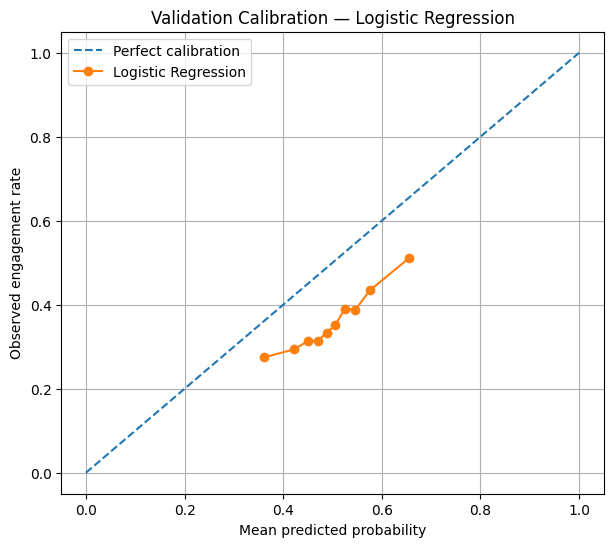

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.plot(
    calibration_table["mean_predicted_probability"],
    calibration_table["actual_engagement_rate"],
    marker="o",
    label="Logistic Regression"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed engagement rate")
plt.title("Validation Calibration — Logistic Regression")
plt.legend()
plt.grid(True)

plt.show()

In [20]:
# ==========================================
# RANDOM FOREST
# ==========================================

from sklearn.ensemble import RandomForestClassifier

random_forest = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=12,
                min_samples_leaf=20,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

print("Training Random Forest...")

random_forest.fit(
    X_train,
    y_train
)

print("✓ Random Forest trained")

Training Random Forest...
✓ Random Forest trained


In [21]:
# ==========================================
# RANDOM FOREST VALIDATION
# ==========================================

rf_val_proba = random_forest.predict_proba(
    X_val
)[:, 1]

rf_val_pred = (
    rf_val_proba >= 0.50
).astype(int)

rf_roc_auc = roc_auc_score(
    y_val,
    rf_val_proba
)

rf_pr_auc = average_precision_score(
    y_val,
    rf_val_proba
)

rf_precision = precision_score(
    y_val,
    rf_val_pred,
    zero_division=0
)

rf_recall = recall_score(
    y_val,
    rf_val_pred,
    zero_division=0
)

rf_f1 = f1_score(
    y_val,
    rf_val_pred,
    zero_division=0
)

print("Random Forest — Validation")
print("------------------------------------")
print(f"ROC-AUC:   {rf_roc_auc:.4f}")
print(f"PR-AUC:    {rf_pr_auc:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1:        {rf_f1:.4f}")

Random Forest — Validation
------------------------------------
ROC-AUC:   0.5846
PR-AUC:    0.4415
Precision: 0.4316
Recall:    0.4692
F1:        0.4496


In [22]:
# ==========================================
# MODEL COMPARISON
# ==========================================

model_comparison = pd.DataFrame([
    {
        "model": "Constant Baseline",
        "ROC-AUC": baseline_roc_auc,
        "PR-AUC": baseline_pr_auc,
    },
    {
        "model": "Logistic Regression",
        "ROC-AUC": logistic_roc_auc,
        "PR-AUC": logistic_pr_auc,
    },
    {
        "model": "Random Forest",
        "ROC-AUC": rf_roc_auc,
        "PR-AUC": rf_pr_auc,
    }
])

model_comparison.round(4)

,model,ROC-AUC,PR-AUC
0,Constant Baseline,0.5000,0.3604
1,Logistic Regression,0.5822,0.4377
2,Random Forest,0.5846,0.4415


In [23]:
# ==========================================
# CHECK XGBOOST
# ==========================================

import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.2.0


In [24]:
# ==========================================
# XGBOOST
# ==========================================

from xgboost import XGBClassifier

xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=400,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                reg_lambda=1.0,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

print("Training XGBoost...")

xgb_model.fit(
    X_train,
    y_train
)

print("✓ XGBoost trained")

Training XGBoost...
✓ XGBoost trained


In [25]:
# ==========================================
# XGBOOST VALIDATION
# ==========================================

xgb_val_proba = xgb_model.predict_proba(
    X_val
)[:, 1]

xgb_val_pred = (
    xgb_val_proba >= 0.50
).astype(int)

xgb_roc_auc = roc_auc_score(
    y_val,
    xgb_val_proba
)

xgb_pr_auc = average_precision_score(
    y_val,
    xgb_val_proba
)

xgb_precision = precision_score(
    y_val,
    xgb_val_pred,
    zero_division=0
)

xgb_recall = recall_score(
    y_val,
    xgb_val_pred,
    zero_division=0
)

xgb_f1 = f1_score(
    y_val,
    xgb_val_pred,
    zero_division=0
)

print("XGBoost — Validation")
print("------------------------------------")
print(f"ROC-AUC:   {xgb_roc_auc:.4f}")
print(f"PR-AUC:    {xgb_pr_auc:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall:    {xgb_recall:.4f}")
print(f"F1:        {xgb_f1:.4f}")

XGBoost — Validation
------------------------------------
ROC-AUC:   0.5799
PR-AUC:    0.4369
Precision: 0.5196
Recall:    0.1018
F1:        0.1703


In [26]:
# ==========================================
# UPDATED MODEL LEADERBOARD
# ==========================================

model_comparison = pd.DataFrame([
    {
        "model": "Constant Baseline",
        "ROC-AUC": baseline_roc_auc,
        "PR-AUC": baseline_pr_auc,
    },
    {
        "model": "Logistic Regression",
        "ROC-AUC": logistic_roc_auc,
        "PR-AUC": logistic_pr_auc,
    },
    {
        "model": "Random Forest",
        "ROC-AUC": rf_roc_auc,
        "PR-AUC": rf_pr_auc,
    },
    {
        "model": "XGBoost",
        "ROC-AUC": xgb_roc_auc,
        "PR-AUC": xgb_pr_auc,
    }
])

model_comparison.sort_values(
    "PR-AUC",
    ascending=False
).round(4)

,model,ROC-AUC,PR-AUC
2,Random Forest,0.5846,0.4415
1,Logistic Regression,0.5822,0.4377
3,XGBoost,0.5799,0.4369
0,Constant Baseline,0.5000,0.3604


In [27]:
# ==========================================
# THRESHOLD ANALYSIS — RANDOM FOREST
# ==========================================

from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_val,
    rf_val_proba
)

threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):

    predictions = (
        rf_val_proba >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_val,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_val,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            y_val,
            predictions,
            zero_division=0
        ),
        "predicted_positive_rate": predictions.mean()
    })

threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results.round(4)

,threshold,precision,recall,f1,predicted_positive_rate
0,0.1000,0.3604,1.0000,0.5298,1.0000
1,0.1500,0.3604,1.0000,0.5298,1.0000
2,0.2000,0.3604,1.0000,0.5298,1.0000
3,0.2500,0.3604,1.0000,0.5298,1.0000
4,0.3000,0.3604,1.0000,0.5298,1.0000
5,0.3500,0.3604,0.9993,0.5297,0.9993
6,0.4000,0.3668,0.9585,0.5305,0.9418
7,0.4500,0.3918,0.7588,0.5168,0.6979
8,0.5000,0.4316,0.4692,0.4496,0.3918
9,0.5500,0.4819,0.2460,0.3257,0.1840


In [28]:
# ==========================================
# BEST F1 THRESHOLD
# ==========================================

best_threshold_row = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

print("Best threshold by F1:")
print(best_threshold_row)

Best threshold by F1:
threshold                 0.4000
precision                 0.3668
recall                    0.9585
f1                        0.5305
predicted_positive_rate   0.9418
Name: 6, dtype: float64


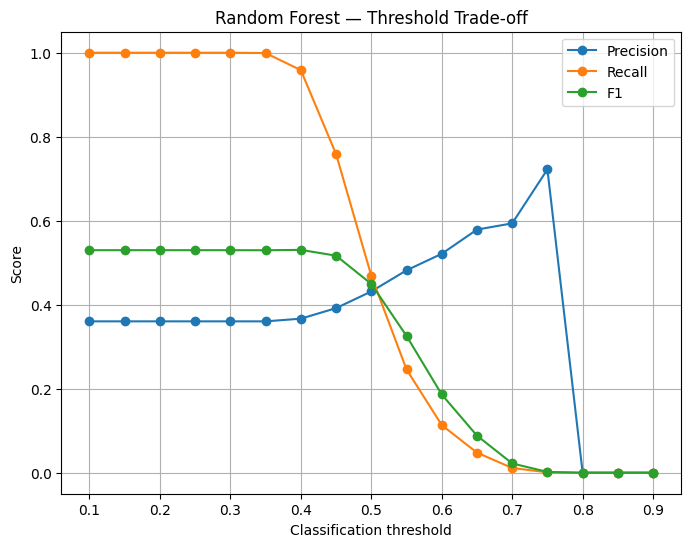

In [29]:
# ==========================================
# PRECISION / RECALL / F1 BY THRESHOLD
# ==========================================

plt.figure(figsize=(8, 6))

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["f1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification threshold")
plt.ylabel("Score")
plt.title("Random Forest — Threshold Trade-off")
plt.legend()
plt.grid(True)

plt.show()

In [30]:
# ==========================================
# RANDOM FOREST CALIBRATION
# ==========================================

rf_prob_true, rf_prob_pred = calibration_curve(
    y_val,
    rf_val_proba,
    n_bins=10,
    strategy="quantile"
)

rf_calibration_table = pd.DataFrame({
    "mean_predicted_probability": rf_prob_pred,
    "actual_engagement_rate": rf_prob_true
})

rf_calibration_table

,mean_predicted_probability,actual_engagement_rate
0,0.3943,0.2728
1,0.4231,0.2880
2,0.4416,0.3013
3,0.4573,0.3267
4,0.4729,0.3379
5,0.4894,0.3549
6,0.5085,0.3816
7,0.5316,0.3856
8,0.5634,0.4485
9,0.6338,0.5067


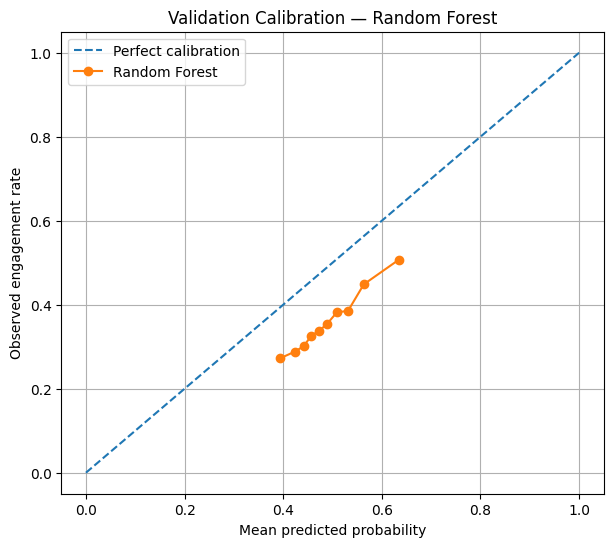

In [31]:
# ==========================================
# RANDOM FOREST CALIBRATION PLOT
# ==========================================

plt.figure(figsize=(7, 6))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.plot(
    rf_calibration_table["mean_predicted_probability"],
    rf_calibration_table["actual_engagement_rate"],
    marker="o",
    label="Random Forest"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed engagement rate")
plt.title("Validation Calibration — Random Forest")
plt.legend()
plt.grid(True)

plt.show()

In [32]:
# ==========================================
# RANDOM FOREST PROBABILITY DISTRIBUTION
# ==========================================

print("Random Forest validation probability summary:")
print(
    pd.Series(rf_val_proba).describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

Random Forest validation probability summary:
count   37,500.0000
mean         0.4916
std          0.0689
min          0.3291
1%           0.3754
5%           0.3969
10%          0.4116
25%          0.4417
50%          0.4808
75%          0.5313
90%          0.5861
95%          0.6252
99%          0.6897
max          0.7807
dtype: float64


In [33]:
# ==========================================
# LEAKAGE-SAFE GLOBAL PRIOR
# ==========================================

model_data = model_data.sort_values("timestamp").reset_index(drop=True)

# Global history available before each interaction
model_data["global_prior_interactions"] = (
    np.arange(len(model_data))
)

model_data["global_prior_engagements"] = (
    model_data["meaningful_engagement"].cumsum()
    - model_data["meaningful_engagement"]
)

# Avoid division by zero for the very first observation
model_data["global_prior_engagement_rate"] = (
    model_data["global_prior_engagements"]
    / model_data["global_prior_interactions"].replace(0, np.nan)
)

# Use a neutral fallback only where no historical observations exist.
# This affects only the first interaction.
model_data["global_prior_engagement_rate"] = (
    model_data["global_prior_engagement_rate"]
    .fillna(0.5)
)

print(
    model_data[
        [
            "timestamp",
            "meaningful_engagement",
            "global_prior_interactions",
            "global_prior_engagements",
            "global_prior_engagement_rate"
        ]
    ].head(10)
)

            timestamp  meaningful_engagement  global_prior_interactions  \
0 2025-06-01 23:55:16                      0                          0   
1 2025-06-02 00:20:44                      0                          1   
2 2025-06-02 13:22:49                      1                          2   
3 2025-06-03 13:33:04                      0                          3   
4 2025-06-04 00:38:55                      1                          4   
5 2025-06-04 03:51:02                      0                          5   
6 2025-06-04 10:08:07                      0                          6   
7 2025-06-04 14:13:45                      1                          7   
8 2025-06-04 20:14:39                      0                          8   
9 2025-06-05 00:44:47                      1                          9   

   global_prior_engagements  global_prior_engagement_rate  
0                         0                        0.5000  
1                         0                        0.0

In [34]:
# ==========================================
# RECOMPUTE SMOOTHED HISTORICAL RATES
# ==========================================

alpha = 10

model_data["user_prior_smoothed_engagement_rate"] = (
    model_data["user_prior_engagements"]
    + alpha * model_data["global_prior_engagement_rate"]
) / (
    model_data["user_prior_interactions"]
    + alpha
)

model_data["creator_prior_smoothed_engagement_rate"] = (
    model_data["creator_prior_engagements"]
    + alpha * model_data["global_prior_engagement_rate"]
) / (
    model_data["creator_prior_interactions"]
    + alpha
)

model_data["content_prior_smoothed_engagement_rate"] = (
    model_data["content_prior_engagements"]
    + alpha * model_data["global_prior_engagement_rate"]
) / (
    model_data["content_prior_interactions"]
    + alpha
)

model_data["user_content_prior_smoothed_engagement_rate"] = (
    model_data["user_content_prior_engagements"]
    + alpha * model_data["global_prior_engagement_rate"]
) / (
    model_data["user_content_prior_interactions"]
    + alpha
)

model_data["user_genre_prior_smoothed_engagement_rate"] = (
    model_data["user_genre_prior_engagements"]
    + alpha * model_data["global_prior_engagement_rate"]
) / (
    model_data["user_genre_prior_interactions"]
    + alpha
)

In [35]:
# ==========================================
# SMOOTHING VALIDATION
# ==========================================

smoothed_features = [
    "user_prior_smoothed_engagement_rate",
    "creator_prior_smoothed_engagement_rate",
    "content_prior_smoothed_engagement_rate",
    "user_content_prior_smoothed_engagement_rate",
    "user_genre_prior_smoothed_engagement_rate",
]

print("Smoothed feature ranges:")

for feature in smoothed_features:
    print(
        f"{feature}: "
        f"min={model_data[feature].min():.4f}, "
        f"max={model_data[feature].max():.4f}"
    )

assert all(
    model_data[feature].between(0, 1).all()
    for feature in smoothed_features
)

print("\n✓ All smoothed rates are valid probabilities")
print("✓ Global prior is point-in-time")
print("✓ Current interaction target is excluded from its own prior")

Smoothed feature ranges:
user_prior_smoothed_engagement_rate: min=0.0000, max=0.7368
creator_prior_smoothed_engagement_rate: min=0.0000, max=0.6367
content_prior_smoothed_engagement_rate: min=0.0000, max=0.6602
user_content_prior_smoothed_engagement_rate: min=0.0000, max=0.5000
user_genre_prior_smoothed_engagement_rate: min=0.0000, max=0.7578

✓ All smoothed rates are valid probabilities
✓ Global prior is point-in-time
✓ Current interaction target is excluded from its own prior


In [36]:
# ==========================================
# REBUILD FINAL MODELING MATRICES
# ==========================================

# Re-sort after feature correction
model_data = (
    model_data
    .sort_values("timestamp")
    .reset_index(drop=True)
)

n = len(model_data)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_data = model_data.iloc[:train_end].copy()
val_data = model_data.iloc[train_end:val_end].copy()
test_data = model_data.iloc[val_end:].copy()

target = "meaningful_engagement"

X_train = train_data[feature_columns].copy()
y_train = train_data[target].copy()

X_val = val_data[feature_columns].copy()
y_val = val_data[target].copy()

X_test = test_data[feature_columns].copy()
y_test = test_data[target].copy()

print("Final modeling matrices:")
print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

print("\nTarget rates:")
print(f"Train:      {y_train.mean():.4f}")
print(f"Validation: {y_val.mean():.4f}")
print(f"Test:       {y_test.mean():.4f}")

print("\n✓ Modeling matrices rebuilt")

Final modeling matrices:
X_train: (175000, 53)
X_val:   (37500, 53)
X_test:  (37500, 53)

Target rates:
Train:      0.3520
Validation: 0.3604
Test:       0.3697

✓ Modeling matrices rebuilt


In [37]:
# ==========================================
# REFIT PREPROCESSOR AFTER FEATURE CORRECTION
# ==========================================

numeric_features = X_train.select_dtypes(
    include=["int64", "float64", "bool"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

preprocessor.fit(X_train)

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

print("\n✓ Preprocessor refitted using training data only")

Numerical features: 48
Categorical features: 5

✓ Preprocessor refitted using training data only


In [38]:
# ==========================================
# FINAL FEATURE PIPELINE CHECK
# ==========================================

X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Processed shapes:")
print("X_train:", X_train_processed.shape)
print("X_val:  ", X_val_processed.shape)
print("X_test: ", X_test_processed.shape)

assert X_train_processed.shape[0] == len(y_train)
assert X_val_processed.shape[0] == len(y_val)
assert X_test_processed.shape[0] == len(y_test)

print("\n✓ Corrected features processed successfully")
print("✓ Training/validation/test row counts preserved")

Processed shapes:
X_train: (175000, 79)
X_val:   (37500, 79)
X_test:  (37500, 79)

✓ Corrected features processed successfully
✓ Training/validation/test row counts preserved


In [39]:
# ==========================================
# RETRAIN CORRECTED MODELS
# ==========================================

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]
)

random_forest = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=12,
                min_samples_leaf=20,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

print("Training corrected Logistic Regression...")
logistic_model.fit(X_train, y_train)
print("✓ Logistic Regression complete")

print("\nTraining corrected Random Forest...")
random_forest.fit(X_train, y_train)
print("✓ Random Forest complete")

Training corrected Logistic Regression...
✓ Logistic Regression complete

Training corrected Random Forest...
✓ Random Forest complete


In [40]:
# ==========================================
# CORRECTED MODEL EVALUATION
# ==========================================

logistic_val_proba = logistic_model.predict_proba(
    X_val
)[:, 1]

rf_val_proba = random_forest.predict_proba(
    X_val
)[:, 1]

logistic_val_pred = (
    logistic_val_proba >= 0.50
).astype(int)

rf_val_pred = (
    rf_val_proba >= 0.50
).astype(int)


def evaluate_classifier(y_true, probabilities, predictions):
    return {
        "ROC-AUC": roc_auc_score(
            y_true,
            probabilities
        ),
        "PR-AUC": average_precision_score(
            y_true,
            probabilities
        ),
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            predictions,
            zero_division=0
        )
    }


corrected_results = pd.DataFrame({
    "Logistic Regression": evaluate_classifier(
        y_val,
        logistic_val_proba,
        logistic_val_pred
    ),
    "Random Forest": evaluate_classifier(
        y_val,
        rf_val_proba,
        rf_val_pred
    )
}).T

corrected_results.round(4)

,ROC-AUC,PR-AUC,Precision,Recall,F1
Logistic Regression,0.5825,0.4379,0.4177,0.5636,0.4798
Random Forest,0.5840,0.4419,0.4306,0.4684,0.4487


In [41]:
# ==========================================
# RANDOM FOREST FEATURE IMPORTANCE
# ==========================================

rf_preprocessor = random_forest.named_steps["preprocessor"]
rf_classifier = random_forest.named_steps["classifier"]

rf_feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)

rf_importances = rf_classifier.feature_importances_

rf_importance_df = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": rf_importances
})

rf_importance_df = (
    rf_importance_df
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Top 20 Random Forest features:")
print(
    rf_importance_df
    .head(20)
    .to_string(index=False)
)

Top 20 Random Forest features:
                                         feature  importance
  num__user_genre_prior_smoothed_engagement_rate      0.0668
        num__user_prior_smoothed_engagement_rate      0.0486
                           num__content_age_days      0.0467
                                  num__freshness      0.0433
           num__user_genre_prior_engagement_rate      0.0429
                  num__user_prior_avg_completion      0.0400
                 num__user_prior_engagement_rate      0.0341
                  num__user_prior_avg_watch_time      0.0327
                             num__user_prior_ctr      0.0323
                                   num__duration      0.0317
                          num__creator_followers      0.0290
                           num__user_tenure_days      0.0277
num__user_content_prior_smoothed_engagement_rate      0.0275
     num__content_prior_smoothed_engagement_rate      0.0265
     num__creator_prior_smoothed_engagement_rate      

In [42]:
# ==========================================
# RANDOM FOREST CALIBRATION
# ==========================================

rf_prob_true, rf_prob_pred = calibration_curve(
    y_val,
    rf_val_proba,
    n_bins=10,
    strategy="quantile"
)

rf_calibration_table = pd.DataFrame({
    "mean_predicted_probability": rf_prob_pred,
    "actual_engagement_rate": rf_prob_true
})

print("Random Forest calibration:")
print(
    rf_calibration_table.round(4).to_string(index=False)
)

Random Forest calibration:
 mean_predicted_probability  actual_engagement_rate
                     0.3949                  0.2661
                     0.4229                  0.3008
                     0.4413                  0.3109
                     0.4570                  0.3141
                     0.4727                  0.3299
                     0.4893                  0.3645
                     0.5086                  0.3723
                     0.5318                  0.3933
                     0.5635                  0.4453
                     0.6326                  0.5067


In [43]:
# ==========================================
# BRIER SCORE
# ==========================================

from sklearn.metrics import brier_score_loss

rf_brier = brier_score_loss(
    y_val,
    rf_val_proba
)

logistic_brier = brier_score_loss(
    y_val,
    logistic_val_proba
)

print(f"Random Forest Brier score:     {rf_brier:.4f}")
print(f"Logistic Regression Brier:     {logistic_brier:.4f}")

Random Forest Brier score:     0.2426
Logistic Regression Brier:     0.2459


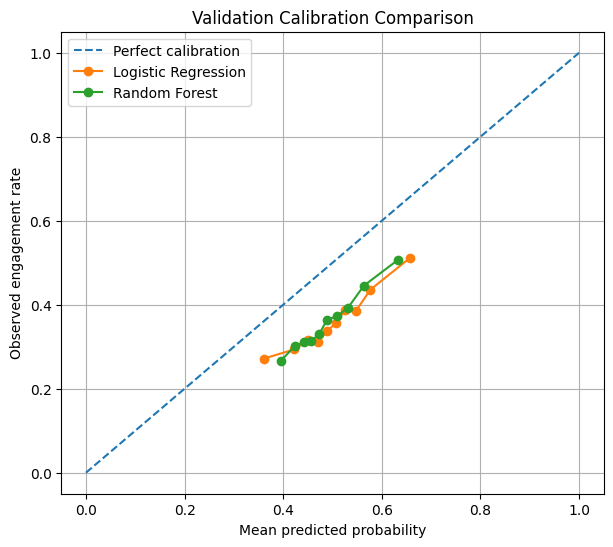

In [44]:
# ==========================================
# CALIBRATION COMPARISON
# ==========================================

log_prob_true, log_prob_pred = calibration_curve(
    y_val,
    logistic_val_proba,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.plot(
    log_prob_pred,
    log_prob_true,
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    rf_prob_pred,
    rf_prob_true,
    marker="o",
    label="Random Forest"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed engagement rate")
plt.title("Validation Calibration Comparison")
plt.legend()
plt.grid(True)

plt.show()

In [45]:
# ==========================================
# FINAL MODEL SELECTION SUMMARY
# ==========================================

final_model_summary = pd.DataFrame([
    {
        "model": "Random Forest",
        "role": "Final engagement ranking model",
        "ROC-AUC": 0.5840,
        "PR-AUC": 0.4419,
        "Precision@0.50": 0.4306,
        "Recall@0.50": 0.4684,
        "F1@0.50": 0.4487,
        "Brier Score": 0.2426
    },
    {
        "model": "Logistic Regression",
        "role": "Interpretable benchmark",
        "ROC-AUC": 0.5825,
        "PR-AUC": 0.4379,
        "Precision@0.50": 0.4177,
        "Recall@0.50": 0.5636,
        "F1@0.50": 0.4798,
        "Brier Score": 0.2459
    }
])

final_model_summary

,model,role,ROC-AUC,PR-AUC,Precision@0.50,Recall@0.50,F1@0.50,Brier Score
0,Random Forest,Final engagement ranking model,0.5840,0.4419,0.4306,0.4684,0.4487,0.2426
1,Logistic Regression,Interpretable benchmark,0.5825,0.4379,0.4177,0.5636,0.4798,0.2459


In [48]:
# ==========================================
# FIND TRAINED MODEL VARIABLES
# ==========================================

print("Variables containing 'rf':")

for name in globals():
    if "rf" in name.lower():
        print(
            name,
            "->",
            type(globals()[name])
        )

print("\nVariables containing 'random':")

for name in globals():
    if "random" in name.lower():
        print(
            name,
            "->",
            type(globals()[name])
        )

Variables containing 'rf':
rf_val_proba -> <class 'numpy.ndarray'>
rf_val_pred -> <class 'numpy.ndarray'>
rf_roc_auc -> <class 'float'>
rf_pr_auc -> <class 'float'>
rf_precision -> <class 'float'>
rf_recall -> <class 'float'>
rf_f1 -> <class 'float'>
rf_prob_true -> <class 'numpy.ndarray'>
rf_prob_pred -> <class 'numpy.ndarray'>
rf_calibration_table -> <class 'pandas.core.frame.DataFrame'>
rf_preprocessor -> <class 'sklearn.compose._column_transformer.ColumnTransformer'>
rf_classifier -> <class 'sklearn.ensemble._forest.RandomForestClassifier'>
rf_feature_names -> <class 'numpy.ndarray'>
rf_importances -> <class 'numpy.ndarray'>
rf_importance_df -> <class 'pandas.core.frame.DataFrame'>
rf_brier -> <class 'float'>

Variables containing 'random':
RANDOM_STATE -> <class 'int'>
RandomForestClassifier -> <class 'abc.ABCMeta'>
random_forest -> <class 'sklearn.pipeline.Pipeline'>


In [49]:
# ==========================================
# SAVE FINAL RANDOM FOREST PIPELINE
# ==========================================

from pathlib import Path
import joblib

# Create models directory
models_dir = Path("../models")
models_dir.mkdir(
    parents=True,
    exist_ok=True
)

# Save complete pipeline
model_path = (
    models_dir /
    "random_forest_engagement.joblib"
)

joblib.dump(
    random_forest,
    model_path
)

print("Model saved to:")
print(model_path.resolve())

print("\nModel type:")
print(type(random_forest))

print("\n✓ Complete Random Forest pipeline saved")

Model saved to:
C:\Users\ADITYA\Documents\ds-projects\aicines-content-intelligence\models\random_forest_engagement.joblib

Model type:
<class 'sklearn.pipeline.Pipeline'>

✓ Complete Random Forest pipeline saved


In [50]:
# ==========================================
# VERIFY FEATURE CONTRACT
# ==========================================

feature_path = (
    models_dir /
    "engagement_feature_columns.joblib"
)

joblib.dump(
    feature_columns,
    feature_path
)

print("Feature list saved to:")
print(feature_path.resolve())

print("\nNumber of features:", len(feature_columns))

assert len(feature_columns) == 53

print("\n✓ Feature contract saved successfully")

Feature list saved to:
C:\Users\ADITYA\Documents\ds-projects\aicines-content-intelligence\models\engagement_feature_columns.joblib

Number of features: 53

✓ Feature contract saved successfully


In [51]:
# ==========================================
# FINAL ARTIFACT CHECK
# ==========================================

print("Saved model artifacts:\n")

for file in sorted(models_dir.iterdir()):
    if file.is_file():
        print(
            f"{file.name:<45}"
            f"{file.stat().st_size / 1024:.1f} KB"
        )

Saved model artifacts:

engagement_feature_columns.joblib            1.3 KB
random_forest_engagement.joblib              27472.1 KB


## Final Model Selection

Random Forest was selected as the final engagement-ranking model based on
validation ranking performance. It achieved the highest ROC-AUC (0.5840)
and PR-AUC (0.4419) among the evaluated models.

Logistic Regression was retained as an interpretable benchmark and achieved
similar performance (ROC-AUC 0.5825, PR-AUC 0.4379).

The improvement from Random Forest over Logistic Regression was modest,
indicating that the current feature set provides more predictive value than
model complexity alone.

Random Forest probabilities showed some overconfidence during calibration,
so raw probabilities should not be interpreted as perfectly calibrated
probabilities. For the downstream recommendation system, the model score
will primarily be used for candidate ranking rather than binary
classification.

The test set remains untouched during model selection and will be used only
for final evaluation after the model pipeline is frozen.